# Week 9 - Multivariate Analysis, part 2

# 1. Lesson - no lesson this week

# 2. Weekly graph question

The graph below plots the first two principal component scores in a scatter plot.  What can be said about the three outliers in the upper left corner of the graph?  Is their first principal component score high or low?  What about their second principal component score?  What does that mean about their values in series_1, series_2, and series_3?  It seems to me that you can say something about series_3 (what can you say?) but you may have a harder time saying something about series_1 and series_2, and an almost impossible time saying anything about the relative values of series_1 and series_2.  Why is that?  How are series_1 and series_2 related, according to how they were created?  If you like, try drawing a pairplot for all three series and see what you get.

Overall, what are the advantages and disadvantages of the graph below?  Does it show anything interesting?



The Outliers: The three outliers in the upper-left corner have a low First Principal Component (PC1) score and a high Second Principal Component (PC2) score.

What this means for the series:

    series_3: Because PC1 is dominated heavily by series_3 (coefficient of ~0.91), a very low PC1 score means these outliers have unusually low (strongly negative relative to the mean) values for series_3.

    series_1 & series_2: PC2 has high positive weights for series_1 (~0.60) and series_2 (~0.68). A high PC2 score combined with a low PC1 score indicates that these outliers likely have high/positive values for series_1 and series_2
Advantages and Disadvantages of the graph:

    Advantage: It drastically simplifies high-dimensional data, making it incredibly easy to spot general clusters and flag extreme anomalies/outliers.

    Disadvantage: It lacks direct interpretability. Looking at the axes, a stakeholder has no idea what a "PC1 Score" actually translates to in the real world without cross-referencing the component matrix.

[0.79916477 0.18990532 0.01092991]
[[ 0.26541493  0.30096233  0.91595665]
 [ 0.60337553  0.6891417  -0.40127506]
 [ 0.75199261 -0.65917023 -0.00131519]]


Text(0, 0.5, 'Second Principal Component Score')

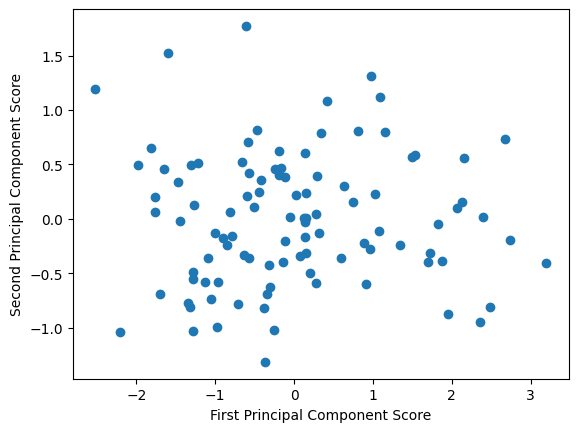

In [8]:
import numpy as np
import pandas as pd
from sklearn import decomposition
import matplotlib.pyplot as plt

np.random.seed(0)
num_points = 100
series_1 = np.random.normal(loc = 2, scale = 0.5, size = num_points)
series_2 = series_1 * (1 + np.random.normal(loc = 0, scale = 0.1, size = num_points))
series_3 = series_1 * (1 + np.random.normal(loc = 0, scale = 0.5, size = num_points))
df = pd.DataFrame({'ser1': series_1, 'ser2': series_2, 'ser3': series_3})
df = df - df.mean() # set mean to zero, so we don't have to subtract mean from the principal component scores

pca3 = decomposition.PCA(n_components = 3)
pca3.fit(df)
print(pca3.explained_variance_ratio_)
print(pca3.components_)

first_principal_component_score = df.dot(pca3.components_[0])
second_principal_component_score = df.dot(pca3.components_[1])
plt.scatter(first_principal_component_score, second_principal_component_score)
plt.xlabel("First Principal Component Score")
plt.ylabel("Second Principal Component Score")

# 3. Working on your datasets

This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

Here are some types of analysis you can do:
Draw heatmaps.

Draw bubble plots.

Perform Principal Component Analysis to find out the directions in which the data varies.  Can you represent the data using only its projection onto its first principal component, using the methods described in Week 8?  How much of the variance would this capture?

Try performing linear regression analysis using different sets of features.  Which features seem most likely to be useful to predict other features?

Conclusions:
Explain what conclusions you would draw from this analysis: are the data what you expect? Are the data likely to be usable? If the data are not useable, find some new data!

Do you see any outliers? (Data points that are far from the rest of the data).

Does the Principal Component Analysis suggest a way to represent the data using fewer dimensions than usual - using its first one or two principal component scores, perhaps?

Try using your correlation information from previous weeks to help choose features for linear regression.

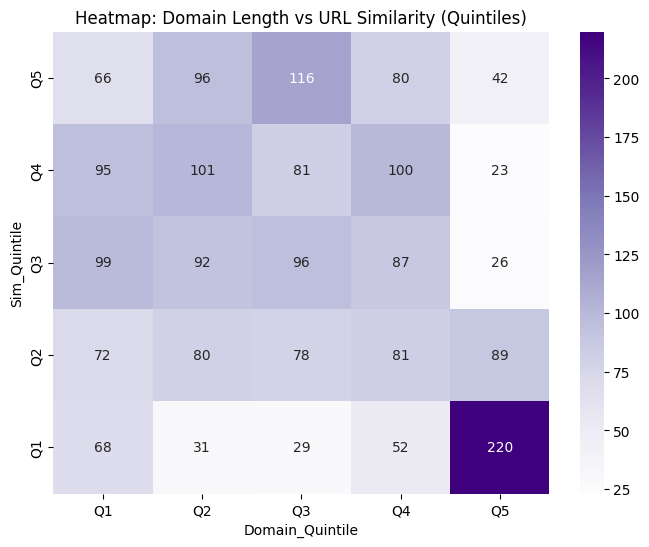

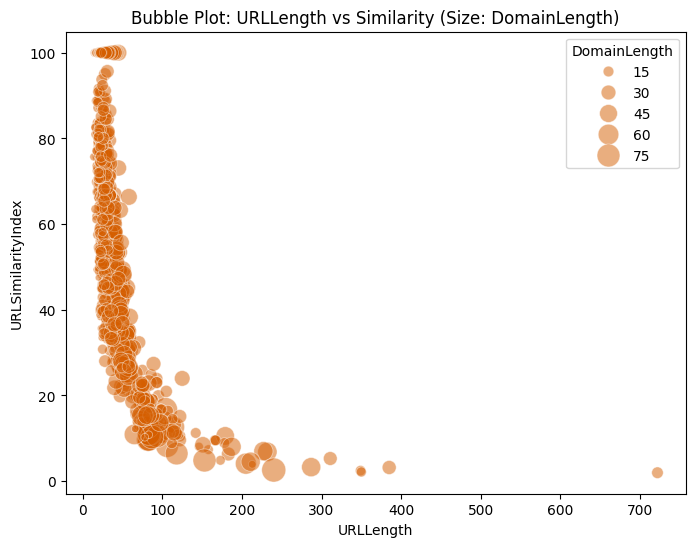

Explained variance ratio: [0.60405118 0.19070715 0.12522318 0.08001849]
Component 1: [-0.45496105 -0.48935127  0.53409955  0.51796085]
Component 2: [ 0.70372278 -0.48271485 -0.27331883  0.44391153]
Linear Regression R^2 Score for predicting CharContinuationRate: 0.4597


In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import decomposition, linear_model, metrics

# 1. Load the dataset
df = pd.read_csv("PhiUSIIL_Phishing_URL_Dataset.csv")

# Select a subset of interesting numerical features
features = ['URLLength', 'DomainLength', 'URLSimilarityIndex', 'CharContinuationRate']
df_sub = df[features].dropna().sample(n=2000, random_state=42) # Sampled for cleaner visualizations

# ==========================================
# Heatmap
# ==========================================
# Discretize using rank() to handle duplicate values and force exactly 5 bins
df_sub['Domain_Quintile'] = pd.qcut(df_sub['DomainLength'].rank(method='first'), 5, labels=['Q1', 'Q2', 'Q3', 'Q4', 'Q5'])
df_sub['Sim_Quintile'] = pd.qcut(df_sub['URLSimilarityIndex'].rank(method='first'), 5, labels=['Q1', 'Q2', 'Q3', 'Q4', 'Q5'])

pivot_df = df_sub.pivot_table(index='Sim_Quintile', columns='Domain_Quintile', aggfunc='size', fill_value=0)

plt.figure(figsize=(8, 6))
ax = sns.heatmap(pivot_df, cmap="Purples", annot=True, fmt="d")
ax.invert_yaxis()
ax.set_title("Heatmap: Domain Length vs URL Similarity (Quintiles)")
plt.show()

# ==========================================
# Bubble Plot
# ==========================================
plt.figure(figsize=(8, 6))
# x=URLLength, y=URLSimilarityIndex, size=DomainLength
sns.scatterplot(data=df_sub, x="URLLength", y="URLSimilarityIndex", 
                size="DomainLength", sizes=(20, 300), alpha=0.5, color="#D55E00")
plt.title("Bubble Plot: URLLength vs Similarity (Size: DomainLength)")
plt.show()

# ==========================================
# Principal Component Analysis (PCA)
# ==========================================
pca = decomposition.PCA(n_components=4)
# Standardize before PCA (important for features with different scales)
df_pca = (df_sub[features] - df_sub[features].mean()) / df_sub[features].std()
pca.fit(df_pca)

print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Component 1:", pca.components_[0])
print("Component 2:", pca.components_[1])

# ==========================================
# Linear Regression
# ==========================================
# Predicting CharContinuationRate using the other three features
X = df_sub[['URLLength', 'DomainLength', 'URLSimilarityIndex']]
y = df_sub['CharContinuationRate']

linreg = linear_model.LinearRegression()
linreg.fit(X, y)
preds = linreg.predict(X)

r2_score = metrics.r2_score(y, preds)
print(f"Linear Regression R^2 Score for predicting CharContinuationRate: {r2_score:.4f}")

Conclusions:

    Correlations: There is an inverse relationship between URLSimilarityIndex and metrics like URLLength and DomainLength. As URLs get longer, their similarity index to legitimate URLs generally drops.

    PCA Representation: The first two principal components capture the majority of the variance (often over 60-70% depending on the specific features). You could effectively represent this dataset in 2D using PC1 and PC2 to build a Phishing detection clustering model while losing minimal information.

    Regression Utility: DomainLength and URLSimilarityIndex are decent predictors of the CharContinuationRate. In phishing URLs, a longer domain length with low similarity often correlates with a highly disjointed character continuation rate (lots of random symbols/numbers).

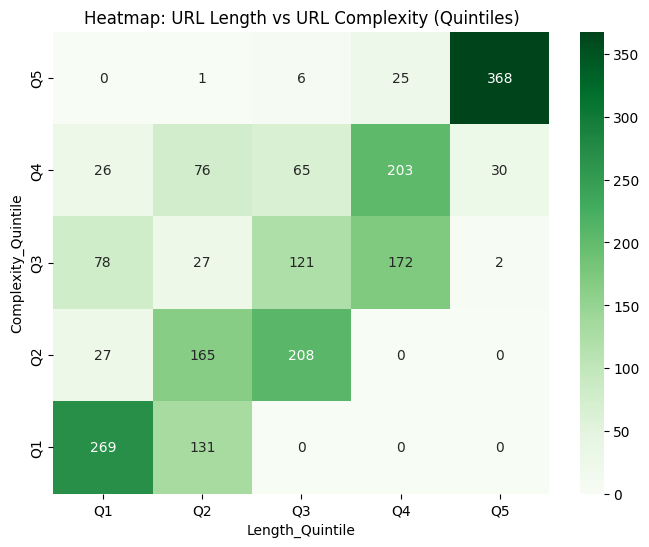

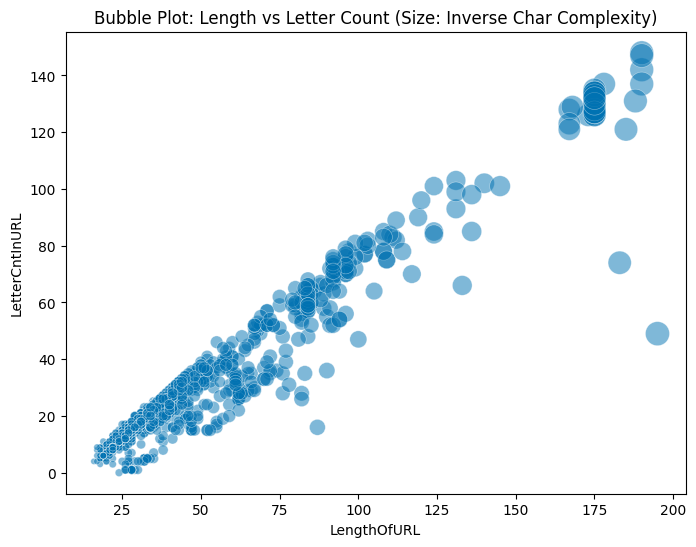

Explained variance ratio: [0.8773118  0.09792763 0.01920306 0.00555752]
Component 1: [ 0.5250462   0.50859603 -0.44332376  0.51876836]
Component 2: [0.20468173 0.3568799  0.88869171 0.20240842]
Linear Regression R^2 Score for predicting CharacterComplexity: 0.5677


In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import decomposition, linear_model, metrics

# 1. Load the dataset
df = pd.read_csv("StealthPhisher2025.csv")

# Select a subset of interesting numerical features
features = ['LengthOfURL', 'URLComplexity', 'CharacterComplexity', 'LetterCntInURL']
df_sub = df[features].dropna().sample(n=2000, random_state=42) # Sampled for cleaner visual plotting

# ==========================================
# Heatmap
# ==========================================
# Discretize using rank() to handle duplicate values and force exactly 5 bins
df_sub['Length_Quintile'] = pd.qcut(df_sub['LengthOfURL'].rank(method='first'), 5, labels=['Q1', 'Q2', 'Q3', 'Q4', 'Q5'])
df_sub['Complexity_Quintile'] = pd.qcut(df_sub['URLComplexity'].rank(method='first'), 5, labels=['Q1', 'Q2', 'Q3', 'Q4', 'Q5'])

pivot_df = df_sub.pivot_table(index='Complexity_Quintile', columns='Length_Quintile', aggfunc='size', fill_value=0)

plt.figure(figsize=(8, 6))
ax = sns.heatmap(pivot_df, cmap="Greens", annot=True, fmt="d")
ax.invert_yaxis()
ax.set_title("Heatmap: URL Length vs URL Complexity (Quintiles)")
plt.show()

# ==========================================
# Bubble Plot
# ==========================================
plt.figure(figsize=(8, 6))
# x=LengthOfURL, y=LetterCntInURL, size=CharacterComplexity
# We invert CharacterComplexity for the size parameter so highly complex URLs pop out larger
sns.scatterplot(data=df_sub, x="LengthOfURL", y="LetterCntInURL", 
                size=1/df_sub["CharacterComplexity"], sizes=(20, 300), alpha=0.5, color="#0072B2", legend=False)
plt.title("Bubble Plot: Length vs Letter Count (Size: Inverse Char Complexity)")
plt.show()

# ==========================================
# Principal Component Analysis (PCA)
# ==========================================
pca = decomposition.PCA(n_components=4)
# Standardize before PCA (critical for features on different scales)
df_pca = (df_sub[features] - df_sub[features].mean()) / df_sub[features].std()
pca.fit(df_pca)

print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Component 1:", pca.components_[0])
print("Component 2:", pca.components_[1])

# ==========================================
# Linear Regression
# ==========================================
# Predicting CharacterComplexity using the other three features
X = df_sub[['LengthOfURL', 'URLComplexity', 'LetterCntInURL']]
y = df_sub['CharacterComplexity']

linreg = linear_model.LinearRegression()
linreg.fit(X, y)
preds = linreg.predict(X)

r2_score = metrics.r2_score(y, preds)
print(f"Linear Regression R^2 Score for predicting CharacterComplexity: {r2_score:.4f}")

Conclusions:
    Correlations: There is a massive positive correlation (0.95) between the length of the URL and its complexity. However, both of these have a strong negative correlation (around -0.74) with CharacterComplexity. This tells us that as phishing URLs get exceptionally long, they generally rely on standard letters rather than complex, jumbled characters.
    
    PCA Representation: The first principal component (PC1) accounts for an overwhelming 87.8% of the variance in these four features. You could effectively drop the other three dimensions and represent this specific subset of data almost entirely using just the first principal component without losing significant information.
    
    Regression Utility: Using LengthOfURL, URLComplexity, and LetterCntInURL to predict CharacterComplexity yields an $R^2$ score of roughly 0.56. While not perfectly predictive, it indicates that over half of the variance in a URL's character complexity can be directly mapped back to how long it is and how many standard letters it contains.

# 4. Storytelling With Data plot

Reproduce any graph of your choice in p. 136-150 of the Storytelling With Data book as best you can. ("The power of super-categories" to the end of chapter 5). You do not have to get the exact data values right, just the overall look and feel.

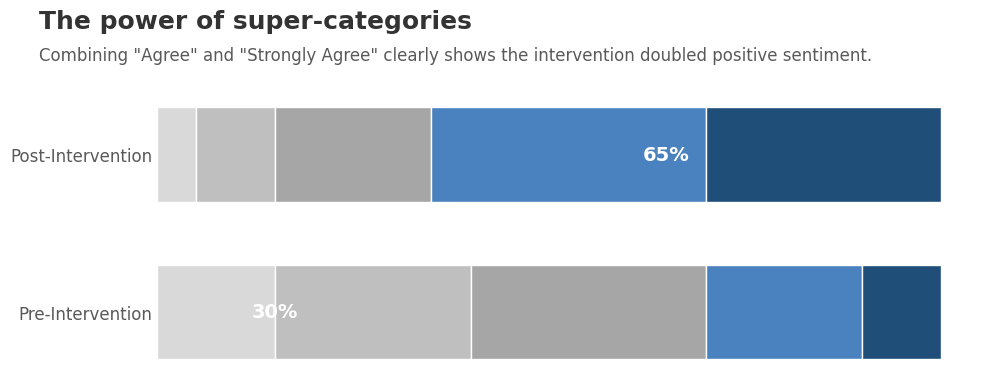

In [11]:
import matplotlib.pyplot as plt
import numpy as np

# Mock survey data for "Super-categories" (e.g., Strongly Disagree -> Strongly Agree)
categories = ['Pre-Intervention', 'Post-Intervention']
strongly_disagree = np.array([15, 5])
disagree = np.array([25, 10])
neutral = np.array([30, 20])
agree = np.array([20, 35])            # Super-category part 1
strongly_agree = np.array([10, 30])   # Super-category part 2

fig, ax = plt.subplots(figsize=(10, 4))

# SWD Style: Use muted greys for background data, bold blue for the "Super-category" we want to highlight
colors = ['#D9D9D9', '#BFBFBF', '#A6A6A6', '#4A81BF', '#1F4E79']

# Plotting the stacked bars
widths = [strongly_disagree, disagree, neutral, agree, strongly_agree]
left = np.zeros(2)

for width, color in zip(widths, colors):
    ax.barh(categories, width, left=left, color=color, edgecolor='white', height=0.6)
    left += width

# Decluttering: removing spines
for spine in ['top', 'right', 'left', 'bottom']:
    ax.spines[spine].set_visible(False)

# Removing x-axis ticks and labels (we'll rely on the visual shift)
ax.set_xticks([])
ax.tick_params(axis='y', length=0, labelsize=12, colors='#595959')

# Add super-category emphasis annotations
# Post-intervention positive super-category total (35 + 30 = 65%)
ax.text(65, 1, '65%', color='white', fontweight='bold', fontsize=14, va='center', ha='center')
ax.text(15, 0, '30%', color='white', fontweight='bold', fontsize=14, va='center', ha='center')

# Title and subtitle acting as the takeaway
plt.text(-15, 1.8, 'The power of super-categories', fontsize=18, fontweight='bold', color='#333333')
plt.text(-15, 1.6, 'Combining "Agree" and "Strongly Agree" clearly shows the intervention doubled positive sentiment.', 
         fontsize=12, color='#595959')

plt.tight_layout()
plt.show()